<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/IMS_2ndtest_RtF_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMS 2nd_test — Run-to-Failure 조기탐지
**트랙:** `onsite_r2f_ims/` (독립 노트북, Paderborn/binary 트랙과 혼용 금지)

**목적:** 같은 베어링의 "정상 초기 등록 → 열화 이탈 조기탐지" 컨셉 검증

**데이터 사양 (고정)**
- 파일명: `2004.02.12.10.32.39` 형식 (타임스탬프 = 시간축)
- 각 파일: 20,480행 × 4열, 탭 구분, 헤더 없음
- 샘플링: 20,480 Hz (파일당 1초 스냅샷)
- 채널: 열0=Bearing1, 열1=Bearing2, 열2=Bearing3, 열3=Bearing4
- 알려진 고장: **Bearing1 외륜(Outer race) 고장** ← 탐지 타깃

**셀 실행 순서: 1→2→3→4→5 (반드시 순서대로)**

In [1]:
# ============================================================
# 셀 1 — 라이브러리 & 드라이브 마운트 & 경로 확인
# ============================================================
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv

from google.colab import drive
drive.mount('/content/drive')

# ---- 경로 (드라이브 구조에 맞게 확인) ----
BASE = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/IMS_NASA'

# 실제 폴더 구조 출력 — 2nd_test 위치 확인용
print('=== IMS_NASA 내부 폴더 구조 ===')
for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level >= 1:   # 2단계까지만 출력
        break

print()
print('[다음 단계]')
print('  출력에서 2nd_test 폴더 위치를 확인하세요.')
print('  경로가 BASE/2nd_test 이면 셀2를 그대로 실행하면 됩니다.')
print('  경로가 BASE/2nd_test/2nd_test 처럼 한 겹 더 있으면 셀2의 TEST2_DIR을 수정하세요.')

Mounted at /content/drive
=== IMS_NASA 내부 폴더 구조 ===
IMS_NASA/
  3rd_test/

[다음 단계]
  출력에서 2nd_test 폴더 위치를 확인하세요.
  경로가 BASE/2nd_test 이면 셀2를 그대로 실행하면 됩니다.
  경로가 BASE/2nd_test/2nd_test 처럼 한 겹 더 있으면 셀2의 TEST2_DIR을 수정하세요.


In [3]:
# ============================================================
# 셀 2 — 파라미터 설정 & 파일 목록 로딩 & 구조 검증
# ============================================================

# ================= 사용자 설정 =================
TEST2_DIR          = BASE + '/2nd_test'   # ← 셀1 출력 보고 필요시 수정
FS                 = 20480                # 샘플링레이트 (IMS 공식)
TARGET_BEARING_COL = 0                    # Bearing1 = 열0 (외륜 고장 타깃)
BASELINE_RATIO     = 0.15                 # 초기 15%를 정상 베이스라인으로 등록
# ==============================================

# 파일 목록 — 타임스탬프 파일명 정렬 = 시간 순서
files = sorted(glob.glob(os.path.join(TEST2_DIR, '*')))
files = [f for f in files
         if re.match(r'.*\d{4}\.\d{2}\.\d{2}', os.path.basename(f))]

print(f'총 파일 수 : {len(files)}  (예상 984)')
print(f'첫  파일   : {os.path.basename(files[0])}')
print(f'마지막 파일: {os.path.basename(files[-1])}')

# 첫 파일로 shape 검증
sample = np.loadtxt(files[0])
print(f'파일 shape : {sample.shape}  (예상 (20480, 4))')

assert len(files) > 0,        '파일을 찾을 수 없음 — TEST2_DIR 경로를 확인하세요'
assert sample.shape[0] == 20480, f'행 수 불일치: {sample.shape[0]} (예상 20480)'
assert sample.shape[1] == 4,     f'열 수 불일치: {sample.shape[1]} (예상 4) — 채널 매핑 재확인'

print()
print('✅ 파일 수·shape 모두 정상 — 셀3으로 진행하세요')

총 파일 수 : 984  (예상 984)
첫  파일   : 2004.02.12.10.32.39
마지막 파일: 2004.02.19.06.22.39
파일 shape : (20480, 4)  (예상 (20480, 4))

✅ 파일 수·shape 모두 정상 — 셀3으로 진행하세요


In [4]:
# ============================================================
# 셀 3 — 물리 특징 추출 (전 구간, ~수 분 소요)
# ============================================================

def extract_features(sig, fs=FS):
    """1초 진동 신호(20480점) → 물리 특징 벡터 9개.
    스케일 정보를 보존하는 절대적 특징 위주 (열화 크기 변화 감지 목적)."""
    x = sig.astype(np.float64)

    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)

    # 포락선(envelope) 에너지 — 베어링 결함 임팩트에 민감
    env     = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))

    # 고주파 에너지 비율 — 초기 결함 신호 포착
    fft_mag   = np.abs(np.fft.rfft(x))
    freqs     = np.fft.rfftfreq(len(x), 1/fs)
    hf_energy = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)

    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf_energy])

FEATURE_NAMES = ['RMS', 'Peak', 'Crest', 'Kurtosis', 'Skew',
                 'P2P', 'Std', 'EnvRMS', 'HF_ratio']

# 타깃 베어링(Bearing1) 전 구간 특징 추출
print(f'Bearing1(열{TARGET_BEARING_COL}) 특징 추출 시작 — {len(files)}개 파일...')
feats = []
for i, f in enumerate(files):
    data = np.loadtxt(f)
    sig  = data[:, TARGET_BEARING_COL]
    feats.append(extract_features(sig))
    if i % 100 == 0:
        print(f'  {i}/{len(files)} 완료...')

feats = np.array(feats)
print()
print(f'✅ 특징 행렬 shape: {feats.shape}  (파일수 × 9)')

Bearing1(열0) 특징 추출 시작 — 984개 파일...
  0/984 완료...
  100/984 완료...
  200/984 완료...
  300/984 완료...
  400/984 완료...
  500/984 완료...
  600/984 완료...
  700/984 완료...
  800/984 완료...
  900/984 완료...

✅ 특징 행렬 shape: (984, 9)  (파일수 × 9)


In [5]:
# ============================================================
# 셀 4 — 베이스라인 등록 & Mahalanobis 이탈 탐지
# ============================================================

# 초기 15%를 "이 베어링의 정상 상태"로 등록
n_base   = int(len(feats) * BASELINE_RATIO)
baseline = feats[:n_base]
print(f'베이스라인 등록: 초기 {n_base}개 파일 (전체의 {BASELINE_RATIO*100:.0f}%)')

# 정규화 기준 — 베이스라인에서만 산출 (미래 정보 누수 방지)
mu      = baseline.mean(axis=0)
sigma   = baseline.std(axis=0) + 1e-12
base_n  = (baseline - mu) / sigma
feats_n = (feats    - mu) / sigma

# Mahalanobis 거리 계산 (베이스라인 공분산 기준)
cov_inv  = pinv(np.cov(base_n.T))
mean_vec = base_n.mean(axis=0)

def mahalanobis(v):
    d = v - mean_vec
    return np.sqrt(d @ cov_inv @ d.T)

md = np.array([mahalanobis(v) for v in feats_n])

# 임계값: 베이스라인 거리 분포의 mean + 3×std
base_md   = md[:n_base]
threshold = base_md.mean() + 3 * base_md.std()
print(f'이탈 임계값 (mean+3std): {threshold:.3f}')

# 첫 이탈 시점 — 임계 초과가 연속 5개 이상 유지된 시점을 "진짜 열화 시작"으로 판정
alarm_idx = None
for i in range(n_base, len(md) - 5):
    if np.all(md[i:i+5] > threshold):
        alarm_idx = i
        break

print()
if alarm_idx is not None:
    lead = len(md) - alarm_idx
    print(f'[조기탐지 성공] 파일 #{alarm_idx} — {os.path.basename(files[alarm_idx])}')
    print(f'  → 실험 종료(고장)까지 {lead}개 파일 앞서 경보')
    print(f'  → 전체 수명 대비 {alarm_idx/len(md)*100:.1f}% 지점에서 경보')
    print(f'  → 리드타임 근사: 파일 간격 ~10분 기준 약 {lead*10}분')
else:
    print('[경보 없음] 임계 이내로 끝까지 유지됨')
    print('  → 아래 튜닝 시도:')
    print('     1) BASELINE_RATIO = 0.10  (베이스라인 축소)')
    print('     2) threshold = base_md.mean() + 2.5 * base_md.std()  (임계 완화)')

베이스라인 등록: 초기 147개 파일 (전체의 15%)
이탈 임계값 (mean+3std): 6.348

[조기탐지 성공] 파일 #532 — 2004.02.16.03.12.39
  → 실험 종료(고장)까지 452개 파일 앞서 경보
  → 전체 수명 대비 54.1% 지점에서 경보
  → 리드타임 근사: 파일 간격 ~10분 기준 약 4520분


/tmp/ipykernel_1362/826970502.py:40: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1362/826970502.py:40: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1362/826970502.py:40: UserWarning: Glyph 49692 (\N{HANGUL SYLLABLE SUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1362/826970502.py:40: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1362/826970502.py:40: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1362/826970502.py:40: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1362/826970502.py:40: UserWarning: Glyph 52629 (\N{HANGUL SYLLABLE CUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

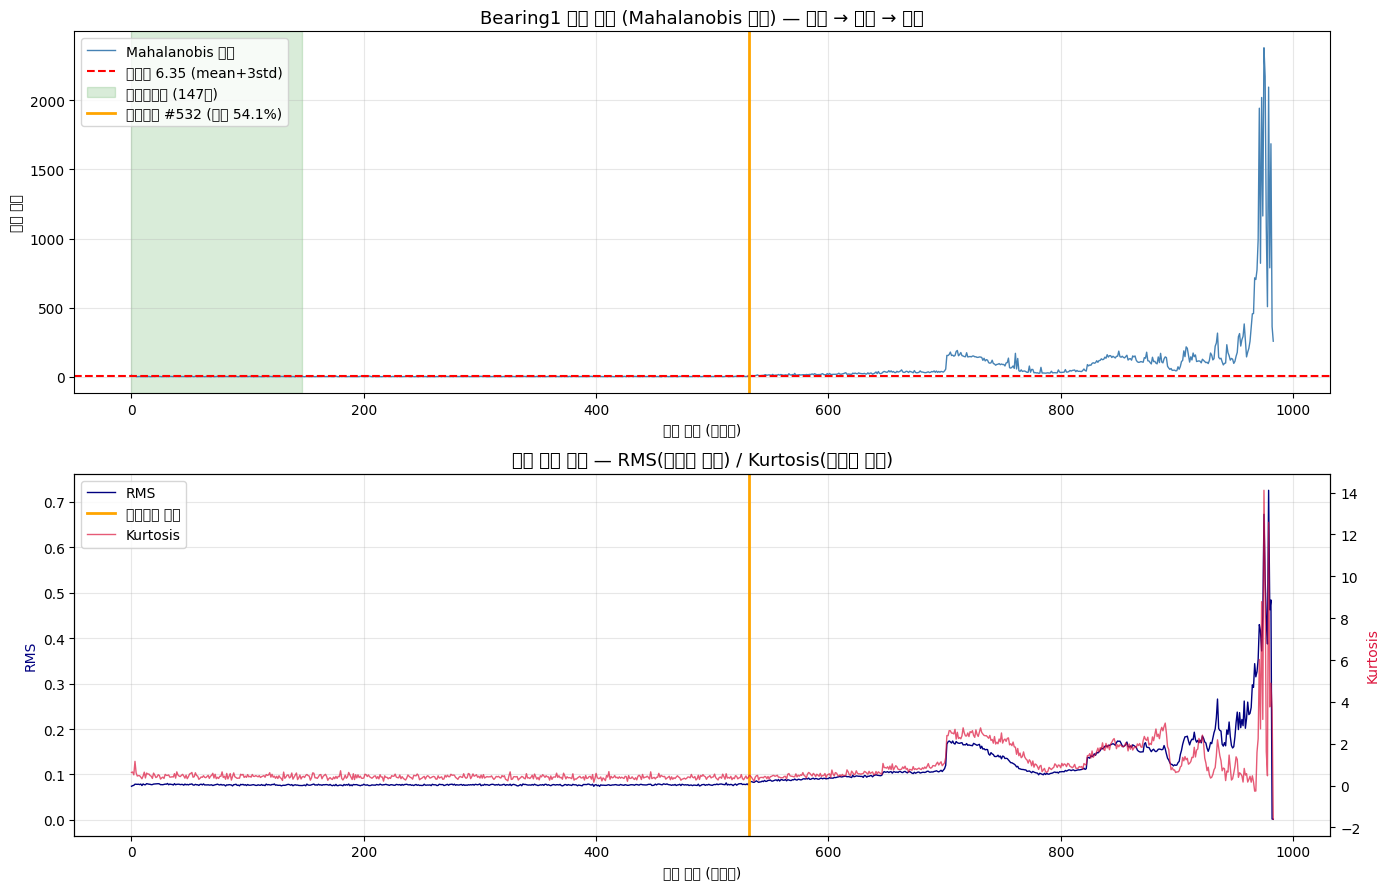

저장 완료: /content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/ims_2ndtest_result.png

  판정 요약
  경보 시점  : 파일 #532 / 전체 984개
  수명 소진율: 54.1%
  리드타임   : 452개 파일 (≈4520분, 근사)
  판정       : ⚠️  오탐 가능성 검토 (너무 이른 경보 — 곡선 모양 확인)


In [6]:
# ============================================================
# 셀 5 — 시각화 & 결과 저장
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- (상) Mahalanobis 거리: 건강 상태 추이 ---
ax0 = axes[0]
ax0.plot(md, color='steelblue', lw=1, label='Mahalanobis 거리')
ax0.axhline(threshold, color='red', ls='--', lw=1.5,
            label=f'임계값 {threshold:.2f} (mean+3std)')
ax0.axvspan(0, n_base, color='green', alpha=0.15, label=f'베이스라인 ({n_base}개)')
if alarm_idx is not None:
    ax0.axvline(alarm_idx, color='orange', lw=2,
                label=f'조기탐지 #{alarm_idx} (수명 {alarm_idx/len(md)*100:.1f}%)')
ax0.set_title('Bearing1 건강 지표 (Mahalanobis 거리) — 정상 → 열화 → 고장',
              fontsize=13)
ax0.set_xlabel('파일 순번 (시간축)')
ax0.set_ylabel('이탈 거리')
ax0.legend(loc='upper left')
ax0.grid(alpha=0.3)

# --- (하) RMS + Kurtosis 추이: 물리 교차 검증 ---
ax1  = axes[1]
ax1b = ax1.twinx()
ax1.plot(feats[:, 0], color='navy',   lw=1,   label='RMS')
ax1b.plot(feats[:, 3], color='crimson', lw=1, alpha=0.7, label='Kurtosis')
if alarm_idx is not None:
    ax1.axvline(alarm_idx, color='orange', lw=2, label='조기탐지 시점')
ax1.set_ylabel('RMS',      color='navy')
ax1b.set_ylabel('Kurtosis', color='crimson')
ax1.set_xlabel('파일 순번 (시간축)')
ax1.set_title('물리 특징 추이 — RMS(에너지 증가) / Kurtosis(충격성 증가)', fontsize=13)
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()

# 결과 저장
out_dir = '/content/drive/My Drive/Colab Notebooks/onsite_r2f_ims/'
os.makedirs(out_dir, exist_ok=True)
out_png = out_dir + 'ims_2ndtest_result.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장 완료: {out_png}')

# 판정 요약 출력
print()
print('=' * 55)
print('  판정 요약')
print('=' * 55)
if alarm_idx is not None:
    pct = alarm_idx / len(md) * 100
    lead = len(md) - alarm_idx
    if pct < 60:
        verdict = '⚠️  오탐 가능성 검토 (너무 이른 경보 — 곡선 모양 확인)'
    elif pct <= 90:
        verdict = '✅  컨셉 검증 성공 (적정 리드타임 확보)'
    else:
        verdict = '⚠️  리드타임 부족 (임계 완화 또는 특징 조정 검토)'
    print(f'  경보 시점  : 파일 #{alarm_idx} / 전체 {len(md)}개')
    print(f'  수명 소진율: {pct:.1f}%')
    print(f'  리드타임   : {lead}개 파일 (≈{lead*10}분, 근사)')
    print(f'  판정       : {verdict}')
else:
    print('  판정: ❌ 경보 없음 — BASELINE_RATIO / 임계 배수 조정 필요')
print('=' * 55)

## 결과 판정 가이드

| 경보 시점(수명%) | 판정 | 조치 |
|:---:|:---:|:---|
| 60~90% | ✅ 성공 | 그대로 확정. RMS·Kurtosis 후반 상승도 교차 확인 |
| 90% 초과 | ⚠️ 늦은 경보 | `threshold = mean + 2.5*std` 로 완화 후 재실행 |
| 60% 미만 | ⚠️ 이른 경보 | 곡선이 진짜 우상향인지 확인. 오탐이면 `BASELINE_RATIO=0.20` 시도 |
| 경보 없음 | ❌ 실패 | `TARGET_BEARING_COL` 을 0→1→2→3 순서로 바꿔 어느 열이 고장 패턴인지 찾기 |

## 튜닝 파라미터 (셀2·셀4 상단)

```python
BASELINE_RATIO     = 0.15   # 조정 범위: 0.10~0.20
TARGET_BEARING_COL = 0      # Bearing1=0, 2=1, 3=2, 4=3
# 셀4 내 임계값 라인:
threshold = base_md.mean() + 3 * base_md.std()   # 3→2.5 으로 완화 가능
```

## 다음 단계
1. **성공** → CLAUDE.md 업데이트: 검증1(Paderborn 자기유지 100%) + 검증2(IMS 조기탐지 성공) = 현장 학습형 컨셉 물리 검증 완료
2. **보너스** → IMS 3rd_test(Bearing3 외륜) 동일 코드로 일반화 확인
3. **이후** → STM32N6 엣지 이식: Mahalanobis + 물리특징 고정소수점 변환